DATASET AQUARIUM
* data validasi = 127 data + anotasi.coco
* data train = 448 data + anotasi.coco
* data test = 64 data + anotasi.coco

TERDAPAT 7 KELAS:
* fish
* jellyfish',
* penguin',
* puffin',
* shark',
* starfish',
* stingray

In [ ]:
import numpy as np # Mengimpor modul NumPy untuk operasi array dan matriks.
import pandas as pd # Mengimpor modul Pandas untuk manipulasi data tabular.
import os # Mengimpor modul os untuk interaksi dengan sistem operasi.
import torch # Mengimpor modul PyTorch untuk pemrosesan tensor dan pembelajaran mesin.
import torchvision # Mengimpor modul torchvision, yang berisi kumpulan alat dan fungsi untuk visi komputer PyTorch.
from torchvision import datasets, models # Mengimpor dataset dan model dari torchvision.
from torchvision.transforms import functional as FT # Mengimpor transformasi fungsi dari torchvision.
from torchvision import transforms as T # Mengimpor modul transforms dari torchvision.
from torch import nn, optim # Mengimpor modul neural network (nn) dan optimasi dari PyTorch.
from torch.nn import functional as F # Mengimpor fungsi-fungsi neural network dari PyTorch.
from torch.utils.data import DataLoader, sampler, random_split, Dataset # Mengimpor modul utilitas data dari PyTorch.
import copy # Mengimpor modul copy untuk salinan objek yang dalam PyTorch sering digunakan dalam pelatihan model.
import math # Mengimpor modul math untuk operasi matematika.
from PIL import Image # Mengimpor modul Image dari PIL (Python Imaging Library) untuk manipulasi gambar.
import cv2 # Mengimpor modul cv2 untuk pengolahan gambar.
import albumentations as A # Mengimpor modul albumentations untuk augmentasi data.

import matplotlib.pyplot as plt # Mengimpor modul matplotlib.pyplot untuk plotting.


In [ ]:
# remove warnings (optional) # Mengimpor modul warnings untuk menghilangkan peringatan.
import warnings # Mengimpor modul warnings untuk menghilangkan peringatan.
warnings.filterwarnings("ignore") # Mengatur pengaturan untuk mengabaikan peringatan.

from collections import defaultdict, deque # Mengimpor modul collections untuk struktur data yang lebih kompleks.
import datetime # Mengimpor modul datetime untuk operasi tanggal dan waktu.
import time # Mengimpor modul time untuk operasi waktu.
from tqdm import tqdm # progress bar # Mengimpor modul tqdm untuk menampilkan bar kemajuan.
from torchvision.utils import draw_bounding_boxes # Mengimpor fungsi draw_bounding_boxes dari modul torchvision.utils.

In [ ]:
print(torch.__version__)
print(torchvision.__version__)

2.3.0+cu121
0.18.0+cu121


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dikarenakan dataset berformat COCO (Common Objects in Context) maka perlu menggunakan alat pypcoco

Pustaka pycocotools menyediakan berbagai fungsi untuk membaca, menafsirkan, dan berinteraksi dengan dataset COCO

In [ ]:
# dataset kita dalam format coco, kita memerlukan alat pypcoco
!pip install pycocotools
from pycocotools.coco import COCO

In [ ]:
# mendefinisikan transformasi
from albumentations.pytorch import ToTensorV2

# **PREPROCESSING**

In [ ]:
def get_transforms(train=False):
   # Fungsi untuk mendapatkan transformasi data untuk training atau inference.
    if train:
        transform = A.Compose([
            # Membuat pipeline augmentasi data dengan menggunakan Albumentations.
            A.Resize(600, 600), # Resize gambar menjadi ukuran 600x600 piksel.
            A.HorizontalFlip(p=0.3), # Flip horizontal dengan probabilitas 0.3.
            A.VerticalFlip(p=0.3), # Flip vertikal dengan probabilitas 0.3.
            A.RandomBrightnessContrast(p=0.1), # Menambahkan variasi kecerahan dan kontras dengan probabilitas 0.1.
            A.ColorJitter(p=0.1), # Menambahkan variasi warna dengan probabilitas 0.1.
            ToTensorV2() # Mengubah gambar dan anotasi menjadi tensor PyTorch.
        ], bbox_params=A.BboxParams(format='coco')) # Menentukan parameter kotak pembatas dalam format COCO.
    else:
        # Jika mode inference, hanya lakukan resizing.
        transform = A.Compose([
            # Membuat pipeline transformasi data untuk mode inference.
            A.Resize(600, 600), # our input size can be 600px
            ToTensorV2() # Mengubah gambar dan anotasi menjadi tensor PyTorch.
        ], bbox_params=A.BboxParams(format='coco')) # Menentukan parameter kotak pembatas dalam format COCO.
    return transform

In [ ]:
class AquariumDetection(datasets.VisionDataset):
    # inisialisasi untuk kelas
    def __init__(self, root, split='train', transform=None, target_transform=None, transforms=None):
        # the 3 transform parameters are reuqired for datasets.VisionDataset
        super().__init__(root, transforms, transform, target_transform)
        self.split = split # Mode dataset: train, valid, test.
        self.coco = COCO(os.path.join(root, split, "_annotations.coco.json")) # Memuat anotasi dataset COCO.
        self.ids = list(sorted(self.coco.imgs.keys())) # Mengambil daftar ID gambar.
        # Hanya menyertakan gambar yang memiliki setidaknya satu anotasi.
        self.ids = [id for id in self.ids if (len(self._load_target(id)) > 0)]

    def _load_image(self, id: int):
       # Memuat gambar dengan ID yang diberikan.
        path = self.coco.loadImgs(id)[0]['file_name']
        image = cv2.imread(os.path.join(self.root, self.split, path)) # Membaca gambar menggunakan OpenCV.
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Mengubah warna gambar ke RGB.
        return image

    def _load_target(self, id):
      # Memuat anotasi untuk gambar dengan ID yang diberikan.
        return self.coco.loadAnns(self.coco.getAnnIds(id))

    def __getitem__(self, index):
         # Mendapatkan item dataset pada indeks tertentu.
        id = self.ids[index] # Mengambil ID gambar pada indeks tertentu.
        image = self._load_image(id) # Memuat gambar.
        target = self._load_target(id) # Memuat anotasi.
        # Melakukan deepcopy anotasi untuk menghindari modifikasi in-place.
        target = copy.deepcopy(self._load_target(id))

        # Mengambil kotak pembatas dan label dari setiap anotasi.
        boxes = [t['bbox'] + [t['category_id']] for t in target] # required annotation format for albumentations
        if self.transforms is not None:
            # Melakukan transformasi menggunakan Albumentations jika tersedia.
            transformed = self.transforms(image=image, bboxes=boxes)

        image = transformed['image'] # Mendapatkan gambar hasil transformasi.
        boxes = transformed['bboxes'] # Mendapatkan kotak pembatas hasil transformasi.

        # Mengubah format kotak pembatas dari xywh menjadi xyxy.
        new_boxes = []
        for box in boxes:
            xmin = box[0]
            xmax = xmin + box[2]
            ymin = box[1]
            ymax = ymin + box[3]
            new_boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.tensor(new_boxes, dtype=torch.float32) # Mengonversi kotak pembatas ke tensor PyTorch.

        # Menyusun target dalam format yang diharapkan oleh model deteksi objek.
        targ = {}
        targ['boxes'] = boxes # Kotak pembatas.
        targ['labels'] = torch.tensor([t['category_id'] for t in target], dtype=torch.int64) # Label kelas.
        targ['image_id'] = torch.tensor([t['image_id'] for t in target]) # ID gambar.
        targ['area'] = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) # Area kotak pembatas.
        targ['iscrowd'] = torch.tensor([t['iscrowd'] for t in target], dtype=torch.int64) # Informasi apakah objek tunggal atau banyak.
        return image.div(255), targ # Skala gambar ke dalam rentang [0, 1] dan kembalikan gambar serta target.

    def __len__(self):
        # Mengembalikan panjang dataset.
        return len(self.ids)

In [ ]:
dataset_path = "/content/drive/MyDrive/viskom/Aquarium Combined"

In [ ]:
#load classes
# Memuat file COCO JSON yang berisi informasi anotasi untuk dataset pelatihan.
coco = COCO(os.path.join(dataset_path, "train", "_annotations.coco.json"))
# Mengambil informasi kategori objek dari dataset COCO.
categories = coco.cats
# Menghitung jumlah kelas atau kategori objek dalam dataset.
n_classes = len(categories.keys())
categories

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


{0: {'id': 0, 'name': 'creatures', 'supercategory': 'none'},
 1: {'id': 1, 'name': 'fish', 'supercategory': 'creatures'},
 2: {'id': 2, 'name': 'jellyfish', 'supercategory': 'creatures'},
 3: {'id': 3, 'name': 'penguin', 'supercategory': 'creatures'},
 4: {'id': 4, 'name': 'puffin', 'supercategory': 'creatures'},
 5: {'id': 5, 'name': 'shark', 'supercategory': 'creatures'},
 6: {'id': 6, 'name': 'starfish', 'supercategory': 'creatures'},
 7: {'id': 7, 'name': 'stingray', 'supercategory': 'creatures'}}

In [ ]:
# Membuat daftar kelas dengan mengambil nama dari setiap kategori objek.
classes = [i[1]['name'] for i in categories.items()]
classes

['creatures',
 'fish',
 'jellyfish',
 'penguin',
 'puffin',
 'shark',
 'starfish',
 'stingray']

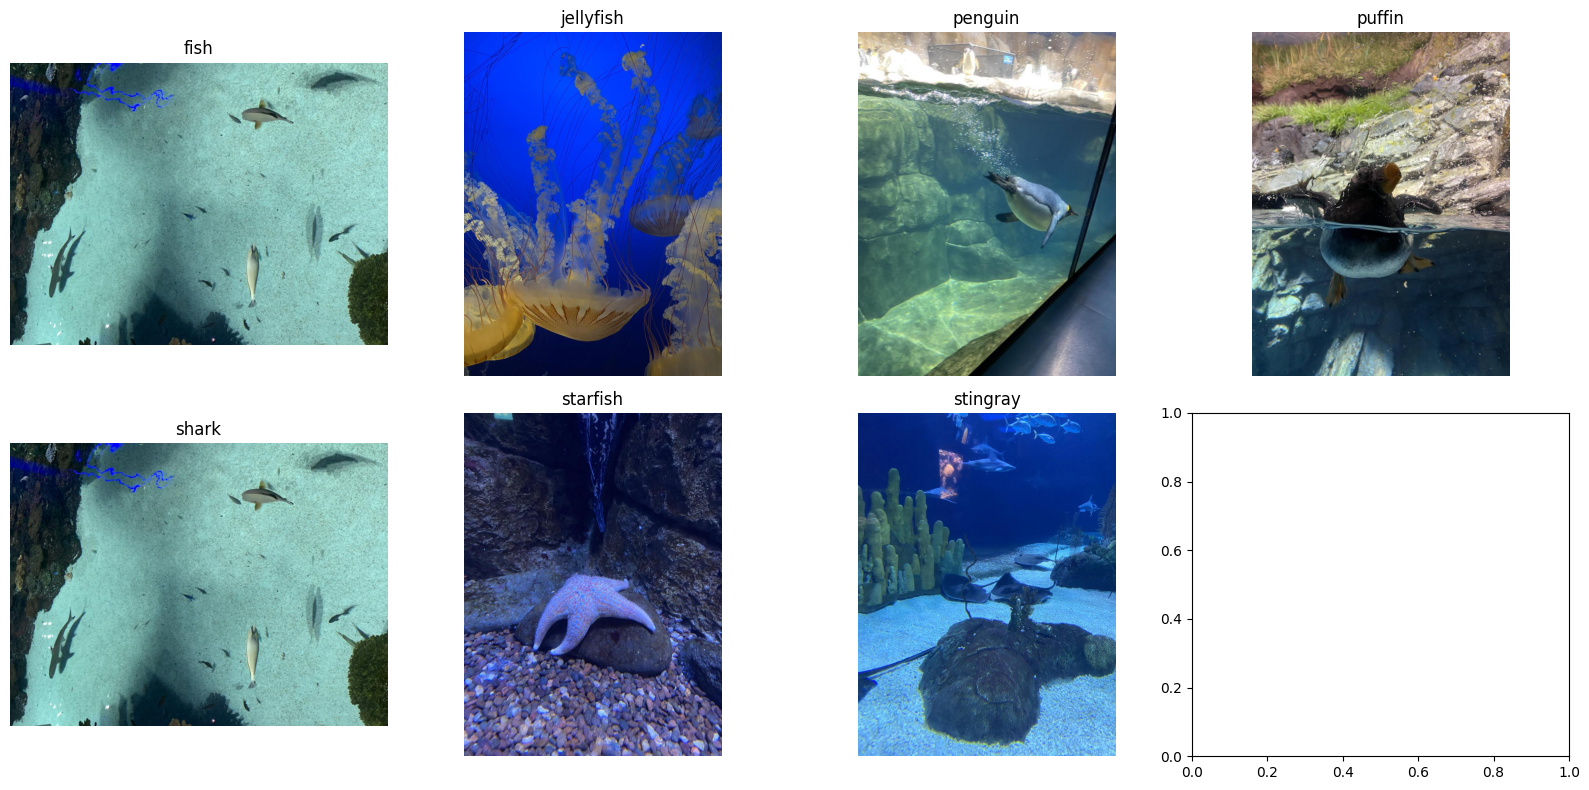

In [ ]:
import math

# Dictionary untuk menyimpan apakah sudah ditampilkan gambar untuk setiap kelas
displayed = {class_id: False for class_id in range(len(classes))}

# Hitung ukuran subplot yang diperlukan
num_classes = len(classes)
rows = int(math.ceil(num_classes / 4))
cols = min(num_classes, 4)

# Buat subplots
fig, axs = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))

# Display 1 gambar untuk setiap kelas
for class_id, class_name in enumerate(classes):
    if not displayed[class_id]:
        # Get image IDs for the specified class
        img_ids = coco.getImgIds(catIds=class_id)

        if img_ids:
            # ambil gambar pertama dari setiap kelas
            img_data = coco.loadImgs(img_ids[0])[0]
            img_path = os.path.join(dataset_path, "train", img_data['file_name'])
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Plot the image on the subplot
            row = (class_id - 1) // cols  # baris
            col = (class_id - 1) % cols    # kolom
            axs[row, col].imshow(image)
            axs[row, col].set_title(class_name)
            axs[row, col].axis('off')

            # Mark the class as displayed
            displayed[class_id] = True

# Hide empty subplots
for i in range(num_classes, rows * cols):
    row = i // cols
    col = i % cols
    axs[row, col].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
train_dataset = AquariumDetection(root=dataset_path, transforms=get_transforms(True))

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


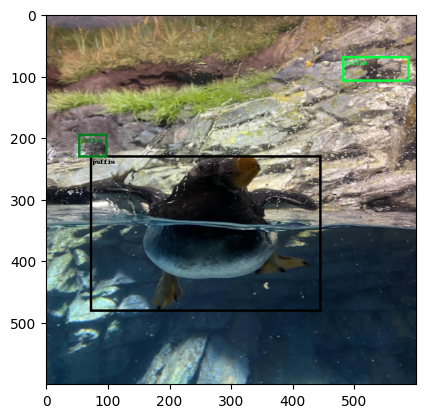

In [ ]:
# Lets view a sample
sample = train_dataset[2]
img_int = torch.tensor(sample[0] * 255, dtype=torch.uint8)
plt.imshow(draw_bounding_boxes(
    img_int, sample[1]['boxes'], [classes[i] for i in sample[1]['labels']], width=4
).permute(1, 2, 0))

In [ ]:
len(train_dataset)

447

In [ ]:
# lets load the faster rcnn model
model = models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=True)
in_features = model.roi_heads.box_predictor.cls_score.in_features # we need to change the head
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, n_classes)

In [ ]:
# Menggabungkan beberapa contoh data individu (gambar dan target) dari dataset menjadi satu batch yang konsisten.
def collate_fn(batch):
    return tuple(zip(*batch))

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4, collate_fn=collate_fn)

In [ ]:
images,targets = next(iter(train_loader))
images = list(image for image in images)
targets = [{k:v for k, v in t.items()} for t in targets]
output = model(images, targets) # just make sure this runs without error

In [ ]:
import torch

# Menggunakan CPU sebagai perangkat pelatihan
device = torch.device("cpu")
model = model.to(device)

optimizer Stochastic Gradient Descent (SGD)

In [ ]:
# Now, and optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.01, momentum=0.9, nesterov=True, weight_decay=1e-4)

In [ ]:
import sys

In [ ]:
def train_one_epoch(model, optimizer, loader, device, epoch):
    model.to(device) # Memindahkan model ke device (GPU atau CPU).
    model.train() # Mengatur model dalam mode pelatihan.

    all_losses = [] # List untuk menyimpan semua nilai loss.
    all_losses_dict = [] # List untuk menyimpan semua nilai loss dalam bentuk dictionary.

    for images, targets in tqdm(loader): # Iterasi melalui data loader.
        images = list(image.to(device) for image in images) # Memindahkan gambar ke device.
        targets = [{k: torch.tensor(v).to(device) for k, v in t.items()} for t in targets] # Memindahkan target ke device.

        # Menghitung loss dari model dengan melewati gambar dan target.
        loss_dict = model(images, targets) # the model computes the loss automatically if we pass in targets
        losses = sum(loss for loss in loss_dict.values()) # Menghitung total loss dari seluruh komponen loss.
        # Mengambil nilai loss dari setiap komponen dan menambahkannya ke dalam list.
        loss_dict_append = {k: v.item() for k, v in loss_dict.items()}
        loss_value = losses.item()

        all_losses.append(loss_value)
        all_losses_dict.append(loss_dict_append)
        # Memeriksa apakah nilai loss adalah finite (tidak infinity atau NaN).
        if not math.isfinite(loss_value):
            print(f"Loss is {loss_value}, stopping trainig") # train if loss becomes infinity
            print(loss_dict)
            sys.exit(1)

        optimizer.zero_grad() # Mengatur gradien parameter ke nol sebelum backward pass.
        losses.backward() # Melakukan backward pass untuk menghitung gradien.
        optimizer.step() # Melakukan satu langkah optimisasi berdasarkan gradien yang dihitung.


    all_losses_dict = pd.DataFrame(all_losses_dict) # Mengonversi list loss dictionary menjadi DataFrame untuk print
    print("Epoch {}, lr: {:.6f}, loss: {:.6f}, loss_classifier: {:.6f}, loss_box: {:.6f}, loss_rpn_box: {:.6f}, loss_object: {:.6f}".format(
        # Mencetak informasi mengenai epoch, learning rate, dan rata-rata loss dari komponen loss.
        epoch, optimizer.param_groups[0]['lr'], np.mean(all_losses),
        all_losses_dict['loss_classifier'].mean(),
        all_losses_dict['loss_box_reg'].mean(),
        all_losses_dict['loss_rpn_box_reg'].mean(),
        all_losses_dict['loss_objectness'].mean()
    ))

In [ ]:
num_epochs=10

for epoch in range(num_epochs):
    train_one_epoch(model, optimizer, train_loader, device, epoch)

100%|██████████| 112/112 [23:57<00:00, 12.84s/it]


Epoch 0, lr: 0.010000, loss: 0.965865, loss_classifier: 0.459026, loss_box: 0.387549, loss_rpn_box: 0.033125, loss_object: 0.086165


100%|██████████| 112/112 [24:22<00:00, 13.05s/it]


Epoch 1, lr: 0.010000, loss: 0.795126, loss_classifier: 0.359075, loss_box: 0.348123, loss_rpn_box: 0.027466, loss_object: 0.060462


100%|██████████| 112/112 [22:56<00:00, 12.29s/it]


...

Epoch 7, lr: 0.010000, loss: 0.636873, loss_classifier: 0.238136, loss_box: 0.349188, loss_rpn_box: 0.021471, loss_object: 0.028078


100%|██████████| 112/112 [20:51<00:00, 11.18s/it]


Epoch 8, lr: 0.010000, loss: 0.612842, loss_classifier: 0.227094, loss_box: 0.336316, loss_rpn_box: 0.021194, loss_object: 0.028238


100%|██████████| 112/112 [21:37<00:00, 11.59s/it]

Epoch 9, lr: 0.010000, loss: 0.649726, loss_classifier: 0.241565, loss_box: 0.359855, loss_rpn_box: 0.021195, loss_object: 0.027111


In [ ]:
model.eval()
torch.cuda.empty_cache()

In [ ]:
test_dataset = AquariumDetection(root=dataset_path, split="test", transforms=get_transforms(False))

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [ ]:
img, _ = test_dataset[5]
img_int = torch.tensor(img*255, dtype=torch.uint8)
with torch.no_grad():
    prediction = model([img.to(device)])
    pred = prediction[0]

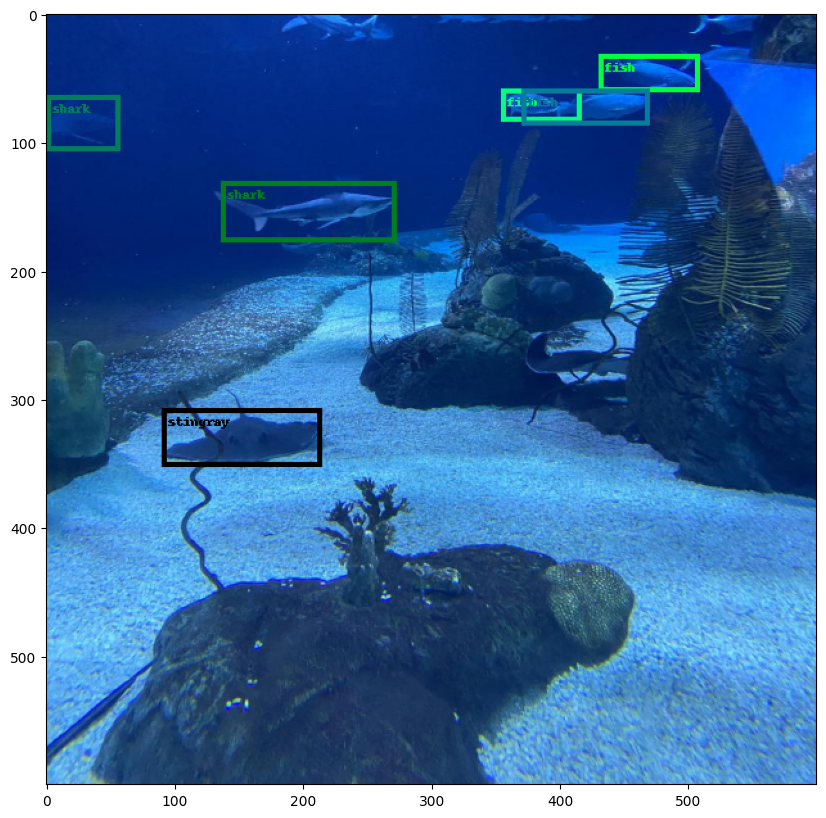

In [ ]:
fig = plt.figure(figsize=(14, 10))
plt.imshow(draw_bounding_boxes(img_int,
    pred['boxes'][pred['scores'] > 0.8],
    [classes[i] for i in pred['labels'][pred['scores'] > 0.8].tolist()], width=4
).permute(1, 2, 0))

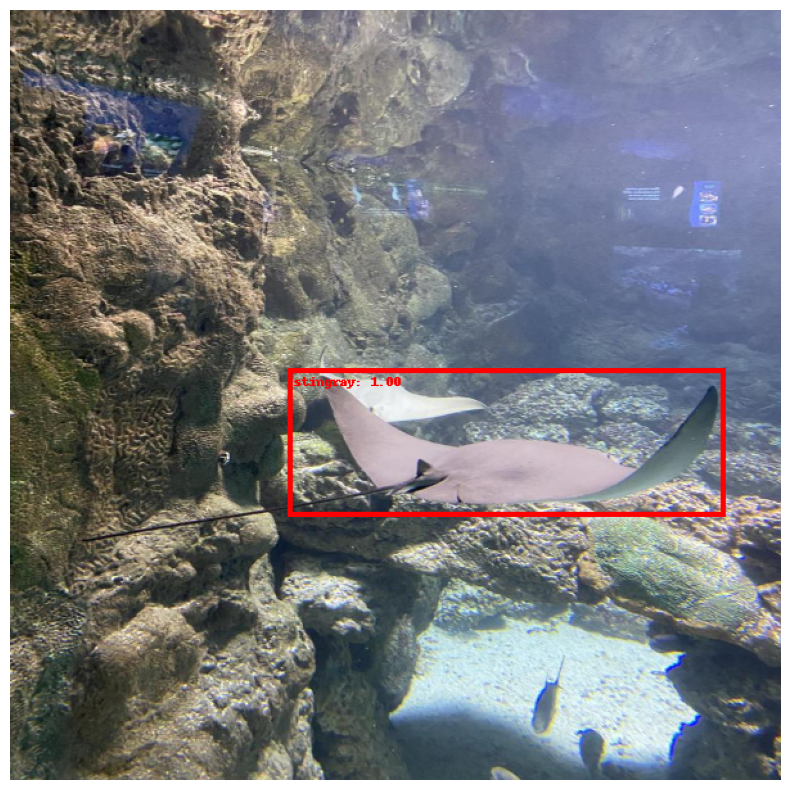

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes

# Get the image and make prediction
img, _ = test_dataset[8]
img_int = torch.tensor(img * 255, dtype=torch.uint8)

# Ensure model is in evaluation mode
model.eval()

with torch.no_grad():
    prediction = model([img.to(device)])
    pred = prediction[0]

# Filter predictions based on a threshold
threshold = 0.8
boxes = pred['boxes'][pred['scores'] > threshold]
labels = [classes[i] for i in pred['labels'][pred['scores'] > threshold].tolist()]
scores = pred['scores'][pred['scores'] > threshold]

# Prepare labels with accuracy
labels_with_scores = [f'{label}: {score:.2f}' for label, score in zip(labels, scores.tolist())]

# Draw bounding boxes
img_with_boxes = draw_bounding_boxes(img_int, boxes, labels_with_scores, width=4, colors='red')

# Display the image with bounding boxes
plt.figure(figsize=(14, 10))
plt.imshow(img_with_boxes.permute(1, 2, 0))
plt.axis('off')  # Hide axis
plt.show()


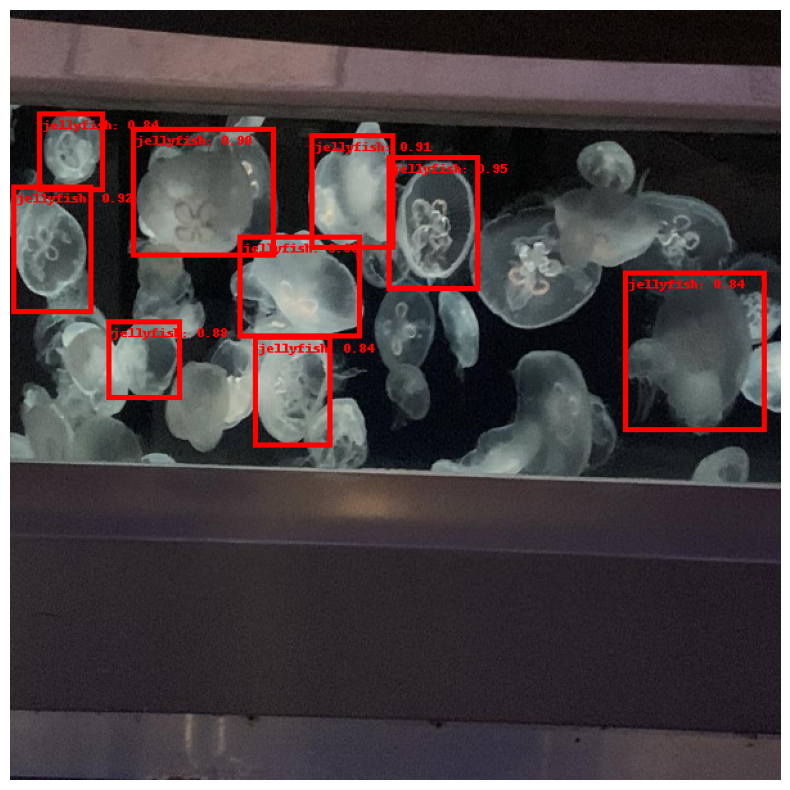

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes

# Get the image and make prediction
img, _ = test_dataset[11]
img_int = torch.tensor(img * 255, dtype=torch.uint8)

# Ensure model is in evaluation mode
model.eval()

with torch.no_grad():
    prediction = model([img.to(device)])
    pred = prediction[0]

# Filter predictions based on a threshold
threshold = 0.8
boxes = pred['boxes'][pred['scores'] > threshold]
labels = [classes[i] for i in pred['labels'][pred['scores'] > threshold].tolist()]
scores = pred['scores'][pred['scores'] > threshold]

# Prepare labels with accuracy
labels_with_scores = [f'{label}: {score:.2f}' for label, score in zip(labels, scores.tolist())]

# Draw bounding boxes
img_with_boxes = draw_bounding_boxes(img_int, boxes, labels_with_scores, width=4, colors='red')

# Display the image with bounding boxes
plt.figure(figsize=(14, 10))
plt.imshow(img_with_boxes.permute(1, 2, 0))
plt.axis('off')  # Hide axis
plt.show()


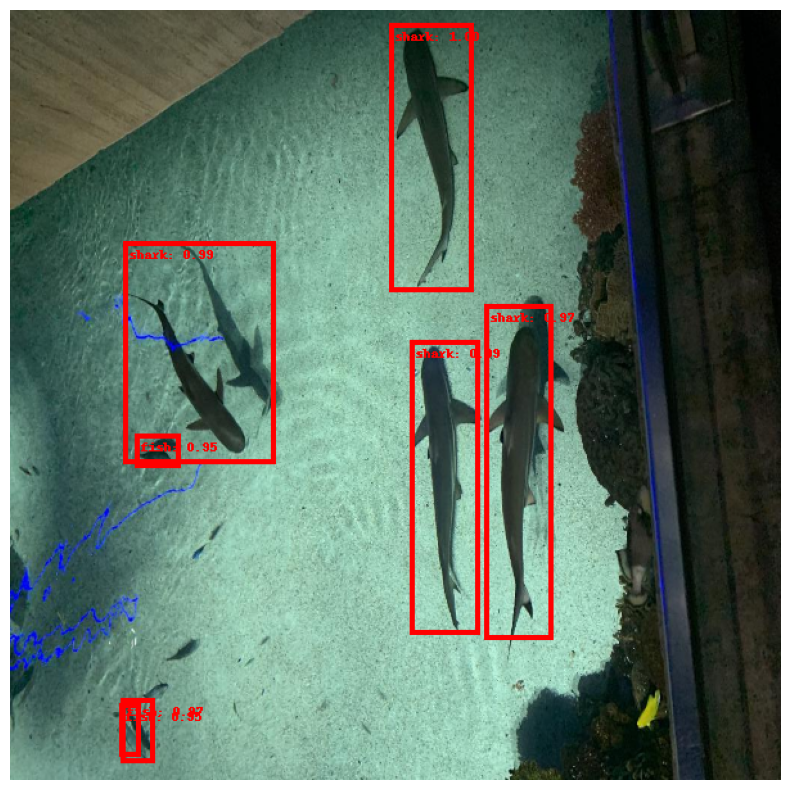

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes

# Get the image and make prediction
img, _ = test_dataset[17]
img_int = torch.tensor(img * 255, dtype=torch.uint8)

# Ensure model is in evaluation mode
model.eval()

with torch.no_grad():
    prediction = model([img.to(device)])
    pred = prediction[0]

# Filter predictions based on a threshold
threshold = 0.8
boxes = pred['boxes'][pred['scores'] > threshold]
labels = [classes[i] for i in pred['labels'][pred['scores'] > threshold].tolist()]
scores = pred['scores'][pred['scores'] > threshold]

# Prepare labels with accuracy
labels_with_scores = [f'{label}: {score:.2f}' for label, score in zip(labels, scores.tolist())]

# Draw bounding boxes
img_with_boxes = draw_bounding_boxes(img_int, boxes, labels_with_scores, width=4, colors='red')

# Display the image with bounding boxes
plt.figure(figsize=(14, 10))
plt.imshow(img_with_boxes.permute(1, 2, 0))
plt.axis('off')  # Hide axis
plt.show()


# **EVALUASI**

In [ ]:
import torch
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import numpy as np

def evaluate_mAP_exclude_invalid_boxes(model, dataset):
    model.eval()
    coco_gt = dataset.coco  # Get the COCO format ground truth annotations

    predictions = []
    image_ids = []  # List to store image ids
    valid_indices = []  # List to store indices of valid entries

    # Logging for invalid bounding boxes
    invalid_entries_log = []

    # Check for valid bounding boxes in the dataset
    for idx in range(len(dataset)):
        if idx in [10, 55, 63]:
            continue  # Skip evaluation for these indices

        img, target = dataset[idx]
        valid = True

        for bbox in target['boxes']:
            if bbox[2] <= bbox[0] or bbox[3] <= bbox[1]:
                valid = False
                invalid_entries_log.append((idx, bbox.tolist()))
                break

        if valid:
            valid_indices.append(idx)

    # Perform predictions only for valid entries
    for idx in valid_indices:
        img, _ = dataset[idx]
        with torch.no_grad():
            prediction = model([img.to(device)])  # Perform prediction
            predictions.extend(prediction)
            image_ids.extend([idx for _ in range(len(prediction))])  # Store image ids

    # Transform predictions to COCO format
    results = []
    for image_id, pred in zip(image_ids, predictions):
        boxes = pred['boxes'].cpu().numpy()
        labels = pred['labels'].cpu().numpy()
        scores = pred['scores'].cpu().numpy()

        for box, label, score in zip(boxes, labels, scores):
            result = {
                'image_id': image_id,
                'category_id': label,
                'bbox': [box[0], box[1], box[2] - box[0], box[3] - box[1]],  # Convert to COCO bbox format (x, y, w, h)
                'score': score
            }
            results.append(result)

    # Log invalid entries if any
    if invalid_entries_log:
        print("Logged invalid entries:")
        for entry in invalid_entries_log:
            print(entry)

    # Initialize COCO evaluator
    coco_dt = coco_gt.loadRes(results)
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # Get mAP results
    print(f"mAP: {coco_eval.stats[0]}")

# Call the function to evaluate mAP, skipping indices 10, 55, and 63
evaluate_mAP_exclude_invalid_boxes(model, test_dataset)


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.54s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

# coba2 load image satu2

In [ ]:
img, _ = test_dataset[0]
img, _ = test_dataset[1]
img, _ = test_dataset[2]
img, _ = test_dataset[3]
img, _ = test_dataset[4]
img, _ = test_dataset[5]
img, _ = test_dataset[6]
img, _ = test_dataset[7]
img, _ = test_dataset[8]
img, _ = test_dataset[9]
# img, _ = test_dataset[10]
img, _ = test_dataset[11]
img, _ = test_dataset[12]
img, _ = test_dataset[13]
img, _ = test_dataset[14]
img, _ = test_dataset[15]
img, _ = test_dataset[16]
img, _ = test_dataset[17]
img, _ = test_dataset[18]
img, _ = test_dataset[19]
img, _ = test_dataset[20]
img, _ = test_dataset[21]
img, _ = test_dataset[22]
img, _ = test_dataset[23]
img, _ = test_dataset[24]
img, _ = test_dataset[25]
img, _ = test_dataset[26]
img, _ = test_dataset[27]
img, _ = test_dataset[28]
img, _ = test_dataset[29]
img, _ = test_dataset[30]
img, _ = test_dataset[31]
img, _ = test_dataset[32]
img, _ = test_dataset[33]
img, _ = test_dataset[34]
img, _ = test_dataset[35]
img, _ = test_dataset[36]
img, _ = test_dataset[37]
img, _ = test_dataset[38]
img, _ = test_dataset[39]
img, _ = test_dataset[40]
img, _ = test_dataset[41]
img, _ = test_dataset[42]
img, _ = test_dataset[43]
img, _ = test_dataset[44]
img, _ = test_dataset[45]
img, _ = test_dataset[46]
img, _ = test_dataset[47]
img, _ = test_dataset[48]
img, _ = test_dataset[49]
img, _ = test_dataset[50]
img, _ = test_dataset[51]
img, _ = test_dataset[52]
img, _ = test_dataset[53]
img, _ = test_dataset[54]
# img, _ = test_dataset[55]
img, _ = test_dataset[56]
img, _ = test_dataset[57]
img, _ = test_dataset[58]
img, _ = test_dataset[59]
img, _ = test_dataset[60]
img, _ = test_dataset[61]
img, _ = test_dataset[62]
# img, _ = test_dataset[63]